### ✅ 1. 라이브러리 불러오기

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import os
from collections import Counter
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

### ✅ 2. 데이터 전처리

In [3]:
# 1. 전체 train 데이터를 불러오고 split
full_df = pd.read_excel("/content/drive/MyDrive/Colab_Notebooks/Projects/NLP/DATASET/Training.xlsx")

# 사람+시스템 문장 합치기
full_texts = full_df[['사람문장1', '시스템문장1', '사람문장2', '시스템문장2', '사람문장3']].fillna('').agg(' '.join, axis=1).tolist()
full_labels = full_df['감정_대분류'].tolist()

# train/val 분할 (예: 80% train, 20% val)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    full_texts, full_labels, test_size=0.2, random_state=42
)

# 2. 기존 Validation.xlsx → Test 데이터로 사용
test_df = pd.read_excel("/content/drive/MyDrive/Colab_Notebooks/Projects/NLP/DATASET/Test.xlsx")
test_texts = test_df[['사람문장1', '시스템문장1', '사람문장2', '시스템문장2', '사람문장3']].fillna('').agg(' '.join, axis=1).tolist()
test_labels = test_df['감정_대분류'].tolist()

# 3. 레이블 인코딩 (train 기준으로 fit)
le = LabelEncoder()
train_encoded_labels = le.fit_transform(train_labels)
val_encoded_labels = le.transform(val_labels)
test_encoded_labels = le.transform(test_labels)

# 3. 감정 레이블 수동 매핑
def map_emotion(label):
    if label == '기쁨':
        return 1
    elif label in ['슬픔', '상처']:
        return 0
    elif label == '분노':
        return 2
    elif label in ['당황', '불안']:
        return 3
    else:
        return -1  # 잘못된 감정 (필터링 대상)

# ✅ 라벨 매핑 적용
train_encoded_labels = [map_emotion(label) for label in train_labels]
val_encoded_labels = [map_emotion(label) for label in val_labels]
test_encoded_labels = [map_emotion(label) for label in test_labels]

# 불필요한 감정 (-1) 필터링 (안 하면 모델 학습 오류 발생)
def filter_invalid(X, y):
    filtered = [(x, label) for x, label in zip(X, y) if label != -1]
    return [x for x, _ in filtered], [y for _, y in filtered]

train_texts, train_encoded_labels = filter_invalid(train_texts, train_encoded_labels)
val_texts, val_encoded_labels = filter_invalid(val_texts, val_encoded_labels)
test_texts, test_encoded_labels = filter_invalid(test_texts, test_encoded_labels)

# 클래스 수 설정
num_classes = 4  # 0 ~ 3


# 4. vocab 생성 (train 기준으로만)
counter = Counter()
for text in train_texts:
    counter.update(text.split())

vocab = {"<pad>": 0, "<unk>": 1}
for idx, (word, _) in enumerate(counter.items(), start=2):
    vocab[word] = idx
vocab_size = len(vocab)

# 5. 인덱스 변환
def encode_text(text, max_len=120):
    tokens = [vocab.get(token, vocab["<unk>"]) for token in text.split()]
    return tokens[:max_len] + [vocab["<pad>"]] * (max_len - len(tokens))

X_train = [encode_text(t) for t in train_texts]
X_val = [encode_text(t) for t in val_texts]
X_test = [encode_text(t) for t in test_texts]

### ✅ 3. Dataset & DataLoader

In [5]:
class EmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(np.array(X), dtype=torch.long)
        self.y = torch.tensor(np.array(y), dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EmotionDataset(X_train, train_encoded_labels)
val_dataset = EmotionDataset(X_val, val_encoded_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


### ✅ 4. 모델 정의

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight)

    def forward(self, input, target):
        logp = self.ce(input, target)
        p = torch.exp(-logp)
        loss = (1 - p) ** self.gamma * logp
        return loss.mean()

class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, vocab_size, embed_dim=200, hidden_dim=128, num_classes=4):
        super(CNN_BiLSTM_Attention, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout_embed = nn.Dropout(0.5)

        # Multi-kernel CNN
        self.conv1_3 = nn.Conv1d(embed_dim, 64, kernel_size=3, padding=1)
        self.conv1_5 = nn.Conv1d(embed_dim, 64, kernel_size=5, padding=2)
        self.conv1_7 = nn.Conv1d(embed_dim, 64, kernel_size=7, padding=3)
        self.dropout_cnn = nn.Dropout(0.5)

        # BiLSTM
        self.lstm = nn.LSTM(input_size=64*3, hidden_size=hidden_dim, bidirectional=True, batch_first=True)
        self.layernorm = nn.LayerNorm(hidden_dim * 2)
        self.dropout_lstm = nn.Dropout(0.5)

        # Attention
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout_attn = nn.Dropout(0.7)

        # Output layer
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout_fc = nn.Dropout(0.7)

    def forward(self, x):
        x = self.embedding(x)                    # [B, L, E]
        x = self.dropout_embed(x)
        x = x.permute(0, 2, 1)                   # [B, E, L]

        x3 = F.relu(self.conv1_3(x))             # [B, 64, L]
        x5 = F.relu(self.conv1_5(x))             # [B, 64, L]
        x7 = F.relu(self.conv1_7(x))             # [B, 64, L]
        x = torch.cat([x3, x5, x7], dim=1)       # [B, 192, L]
        x = self.dropout_cnn(x)
        x = x.permute(0, 2, 1)                   # [B, L, 192]

        lstm_out, _ = self.lstm(x)               # [B, L, 2H]
        lstm_out = self.layernorm(lstm_out)
        lstm_out = self.dropout_lstm(lstm_out)

        weights = torch.softmax(self.attention(lstm_out), dim=1)  # [B, L, 1]
        weights = self.dropout_attn(weights)
        context = torch.sum(weights * lstm_out, dim=1)            # [B, 2H]

        context = self.dropout_fc(context)
        return self.fc(context)                  # [B, num_classes]


### ✅ 5. 학습

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_BiLSTM_Attention(
    vocab_size=vocab_size,
    embed_dim=200,              # ✅ 임베딩 차원 증가
    hidden_dim=128,             # ✅ LSTM 표현력 증가
    num_classes=num_classes
).to(device)

class_weights = compute_class_weight('balanced', classes=np.unique(train_encoded_labels), y=train_encoded_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = FocalLoss(gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)

patience = 3
no_improve_epochs = 0
best_loss = float('inf')
num_epochs = 30  # ✅ 더 많은 에폭 허용

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}")
    for X_batch, y_batch in loop:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []

    val_loop = tqdm(val_loader, desc=f"[Val] Epoch {epoch+1}")
    with torch.no_grad():
        for X_batch, y_batch in val_loop:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(all_labels, all_preds)
    scheduler.step(avg_val_loss)

    print(f"✅ Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.4f}")

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        save_path = "/content/drive/MyDrive/Colab_Notebooks/Projects/NLP/models/best_model.pt"
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'vocab': vocab,
            'label_encoder': le
        }, save_path)
        print("✅ Best model saved.")
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1
        print(f"⚠ No improvement for {no_improve_epochs} epoch(s)")

    if no_improve_epochs >= patience:
        print("🛑 Early stopping triggered.")
        break


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
[Val] Epoch 1: 100%|██████████| 323/323 [00:00<00:00, 329.88it/s]


✅ Epoch 1: Train Loss=0.7271, Val Loss=0.6462, Val Acc=0.3747
✅ Best model saved.


[Val] Epoch 2: 100%|██████████| 323/323 [00:00<00:00, 346.09it/s]


✅ Epoch 2: Train Loss=0.6654, Val Loss=0.5985, Val Acc=0.4390
✅ Best model saved.


[Val] Epoch 3: 100%|██████████| 323/323 [00:00<00:00, 345.20it/s]


...

✅ Epoch 28: Train Loss=0.1546, Val Loss=0.1979, Val Acc=0.7158
✅ Best model saved.


[Val] Epoch 29: 100%|██████████| 323/323 [00:00<00:00, 346.36it/s]


✅ Epoch 29: Train Loss=0.1408, Val Loss=0.2115, Val Acc=0.7057
⚠ No improvement for 1 epoch(s)


[Val] Epoch 30: 100%|██████████| 323/323 [00:01<00:00, 319.90it/s]

✅ Epoch 30: Train Loss=0.1359, Val Loss=0.2151, Val Acc=0.7029
⚠ No improvement for 2 epoch(s)


In [11]:
# ✅ Colab용 파일 업로드
from google.colab import files
# ✅ 모델 저장
torch.save(model.state_dict(), 'cnn_bilstm_attention.pt')
files.download('cnn_bilstm_attention.pt')  # 로컬로 다운로드

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### ✅ 6. 검증

최종 Test 결과:
              precision    recall  f1-score   support

    슬픔/상처(0)       0.73      0.80      0.76      2010
       기쁨(1)       0.97      0.88      0.92      1213
       분노(2)       0.72      0.72      0.72      1257
    불안/당황(3)       0.79      0.76      0.77      2161

    accuracy                           0.78      6641
   macro avg       0.80      0.79      0.79      6641
weighted avg       0.79      0.78      0.79      6641



/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49836 (\N{HANGUL SYLLABLE SEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54548 (\N{HANGUL SYLLABLE PEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


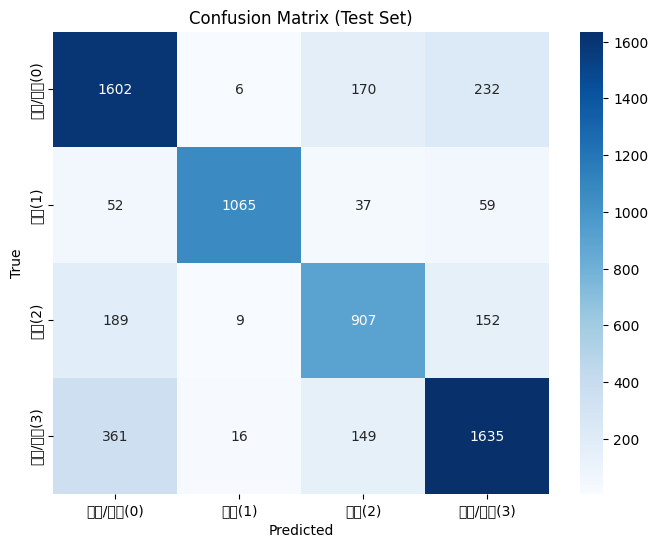


❌ 잘못 예측한 샘플 수: 1432

🔍 잘못된 예측 목록 (문장 | 정답 | 예측):

[문장] 오늘 애들이 날 때렸어. 그런데 난 아무런 저항도 할 수 없었어. 아이들에게 맞는 상황인데 아무런 저항도 할 수 없어 마음이 아프셨군요. 내가 겁이 많은 탓인지 누군가에게 맞는 상황이 되면 몸이 굳어서 안 움직여. 겁이 많아서 몸이 굳어버리시는군요. 어떻게 하는 것이 이 상황을 벗어나는 데 도움이 될까요? 아무래도 운동을 배워봐야 할 것 같아. 부모님께 이야기해서 학원에 다녀야겠어.
→ [정답] 슬픔/상처 | [예측] 불안/당황
----------------------------------------------------------------------------------------------------
[문장] 친구들이 요즘 나를 따돌려. 내가 혼자라는 게 너무 슬퍼. 혼자 된 기분이 너무 슬프겠어요. 내가 한 친구랑 싸웠는데 친구들이 나랑 싸운 친구 편만 들더라. 친구들이 싸운 친구의 편만 들어서 많이 외로우셨겠어요. 나중에 그 친구에게 왜 그랬는지 자세히 들어보고 싶어.
→ [정답] 불안/당황 | [예측] 슬픔/상처
----------------------------------------------------------------------------------------------------
[문장] 믿었던 친구에게 솔직한 내 생각을 전부 얘기했는데 그 친구도 날 떠나버렸어. 외로워. 믿었던 친구에게 이해를 받지 못해 외롭군요. 친구가 나를 받아들여 줬으면 좋겠어. 그런 상황을 변화시키려면 어떻게 하면 될까요? 친구가 이해 못 하는 부분을 다시 얘기해주고 싶어.
→ [정답] 불안/당황 | [예측] 슬픔/상처
----------------------------------------------------------------------------------------------------
[문장] 선생님은 그래도 나를 이해해주실 줄 알았는데 정말 실망했어.

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Best 모델 로드
checkpoint = torch.load("/content/drive/MyDrive/Colab_Notebooks/Projects/NLP/models/best_model.pt", weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

# ✅ 테스트셋 준비
test_dataset = EmotionDataset(X_test, test_encoded_labels)
test_loader = DataLoader(test_dataset, batch_size=32)

# ✅ 예측 수행
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# ✅ 클래스 이름 직접 지정
target_names = ['슬픔/상처(0)', '기쁨(1)', '분노(2)', '불안/당황(3)']

# ✅ 성능 보고
print("최종 Test 결과:")
print(classification_report(all_labels, all_preds, target_names=target_names))

# ✅ Confusion Matrix 시각화
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# ✅ 감정 번호 → 감정명 매핑
label_map = {
    0: "슬픔/상처",
    1: "기쁨",
    2: "분노",
    3: "불안/당황"
}

# ✅ 잘못 예측한 데이터 추출
wrong_indices = [i for i, (pred, true) in enumerate(zip(all_preds, all_labels)) if pred != true]

print(f"\n❌ 잘못 예측한 샘플 수: {len(wrong_indices)}\n")
print("🔍 잘못된 예측 목록 (문장 | 정답 | 예측):\n")

for i in wrong_indices:
    print(f"[문장] {test_texts[i]}")
    print(f"→ [정답] {label_map[all_labels[i]]} | [예측] {label_map[all_preds[i]]}")
    print("-" * 100)